# Machine Learning for Security (MLSec) en Ciberdefensa
# Del Ciclo de Datos a un NIDS Automatizado en Cyber Range

***[Autor](https://www.linkedin.com/in/carlospradobigdata/) :*** ***Carlos Alberto Gómez Prado***   
*DS / ML / GenAI / CyberDefense*    

## Sistema Defensivo con Inteligencia Artificial
Este laboratorio práctico recorre de forma rigurosa el ciclo completo de la ciencia de datos aplicada a la **Defensa**, **Inteligencia** y **Gobierno** (Ciberdefensa). Diseñado para guiar tanto a perfiles en formación como a profesionales avanzados, el recorrido abarca desde la captura de telemetría de red en tiempo real dentro de un Cyber Range, pasando por el Análisis Exploratorio de Datos **(EDA)** y la Ingeniería de Características, hasta el entrenamiento de modelos de Machine Learning y su despliegue para la inferencia y defensa automatizada mediante un **NIDS** (Network-based Intrusion Detection System).

A diferencia de un **IDS** genérico o centrado en el host, este sistema opera a nivel de red, analizando el tráfico bruto (raw packets) y los flujos de comunicación para detectar patrones anómalos e intentos de intrusión de manera automatizada.

**Nivel de Dificultad:**  
Este laboratorio está diseñado para que puedas ejecutarlo y comprenderlo de punta a punta, incluso si estás dando tus primeros pasos. Aunque no requiere experiencia previa, es recomendado tener una noción de informática y redes para instalar los entornos y explorar la bibliografía y los recursos sugeridos para profundizar y enriquecer el conocimiento general de lógica detrás de cada proceso.

* Ciberseguridad | Redes: **Nivel Básico**
* Ciencia de Datos: **Niveles Básico** | **Medio**

**⚠️ Observaciones de Requerimiento, Seguridad y Ética:**

* **Requisitos del Entorno:** Es necesario, **(obligatorio)** contar con un entorno hipervisor como [Virtual Box](https://www.virtualbox.org/) con 2 maquinas virtuales. Instalar todos los paquetes necesarios y configuarlo como "Red Interna" (aislada, comprobar que respondan al **ping**). Una maquina virtual de ataque (`10.0.0.4, 255.255.255.0`) en este caso se usa [Kali Linux](https://www.kali.org/) y una maquina virtual objetivo (`10.0.0.5 , 255.255.255.0`), para este caso se utiliza [Metaexploitable](https://sourceforge.net/projects/metasploitable/). Además se debe instalar [Jupyter Notebook](https://jupyter.org/) y ejecutar con privilegios de administrador (`root`) para permitir la inspección de paquetes, e instalar las librerias y dependencias.
   * Instalar Jupyter `pip3 install jupyter` Notebook o Lab.
   * Crear el entorno virtual `python3 -m venv env`.   
   * Activar el entorno virtual `source env/bin/activate`.   
   * Instalar librerías dentro del entorno: `pip3 install pandas numpy scapy seaborn matplotlib scikit-learn joblib`.
   * Nota: Los módulos `random`, `warnings`, `time`, `subprocess` y `threading` ya vienen incluidos por defecto en la biblioteca estándar de Python.
   * Ejemplo permiso root: `cd ~/ia_cyber_range && sudo ./env/bin/jupyter notebook --allow-root`.
   * En caso de error de socket al ejecutar la celda en Jupyter, se deberá cerrar y volver a abrir el entorno asegurándose de tener permisos de root.
   * Acceso: Ingresar desde `http://localhost:8888` en el navegador. 
* **Restricciones de la Nube:** **NO** ejecute este código en entornos 100% cloud (como Google Colab o similares). La generación de tráfico ofensivo y la apertura de sockets crudos (*raw sockets*) violan los términos de servicio de la mayoría de los proveedores y resultarán en la suspensión inmediata de su cuenta.

* **Uso Responsable:** Ejecutar estas prácticas bajo un marco de aislamiento garantiza la seguridad de los procesos , bucles y el cumplimiento de los estándares éticos y legales vigentes. Este laboratorio ha sido diseñado con fines estrictamente académicos y de investigación en ciberdefensa. El autor no se hace responsable del mal uso del material. Todo el código, las librerías y la información utilizada son de acceso público y libre.

## Índice de Contenidos
---
### 1. Bibliotecas, Dependencias y Configuración del Entorno
* 1.1. Análisis y Manipulación de Datos Estructurados
* 1.2. Redes e Interacción de Paquetes
* 1.3. Visualización de Datos y Métricas
* 1.4. Machine Learning: Preprocesamiento y Modelado (Scikit-Learn)
* 1.5. Evaluación del Modelo y Métricas
* 1.6. Utilidades del Sistema
* 1.7. Declaración de librerias
  
### 2. Captura de Datos: Escenario Inicial
* 2.1. Captura de Tráfico de Red en Tiempo Real
* 2.2. Simulación y Registro del Ataque de Reconocimiento (Nmap)

### 3. Análisis Exploratorio de Datos (EDA)
* 3.1. Análisis de la Estructura de Datos
* 3.2. Mapa de Calor de Ataques (Scatter Plot / Histograma 2D)
* 3.3. Distribución del Tamaño de los Paquetes (Histograma de Densidad)
* 3.4. Matriz de Correlación Temática (Heatmap)

### 4. Preprocesamiento e Ingeniería de Características
* 4.1. Limpieza y Transformación del Escaneo
* 4.2. Análisis a Nivel de Flujo (*Flow-Level*)

### 5. Ampliación del Dataset: Segundo Escenario Ofensivo
* 5.1. Replicación de Estructura para el Nuevo Escenario
* 5.2. Simulación Ofensiva (SYN Flood DoS)
* 5.3. Fusión de Tráfico y Construcción del Dataset Final de Entrenamiento
* 5.4. Visualización del Comportamiento de los Ataques (Scatter Plot)

### 6. Modelado Predictivo: Creación del Baseline
* 6.1. Entrenamiento del Modelo Base (*Random Forest Classifier*)
* 6.2. Ajuste de Hiperparámetros (*Tuning*)
* 6.3. Validación del Motor IDS en Memoria
* 6.4. Serialización y Guardado Local del Modelo Final

### 7. Sistema de Detección de Intrusos (NIDS) en Tiempo Real
* 7.1. Carga, Despliegue y Prueba en Vivo (El Defensor Virtual)

### 8. Referencias y Bibliografía

### 1. Bibliotecas, Dependencias y Configuración del Entorno 
El desarrollo de este laboratorio requiere la integración de herramientas tanto del ecosistema de redes como del ecosistema analítico de Python. A continuación se detalla la función de cada módulo importado:

**1.1. Análisis y Manipulación de Datos Estructurados**

* **pandas (pd):** Fundamental para la estructuración y manipulación de datos tabulares (DataFrames). Se utiliza para almacenar, filtrar y procesar los registros de telemetría de red.

* **numpy (np):** Biblioteca base para la computación científica en Python. Se emplea para operaciones numéricas de alto rendimiento y la generación estocástica de datos sintéticos (ruido y varianza).

**1.2. Redes e Interacción de Paquetes**

* **scapy.all (sniff, IP, TCP, UDP, send):** El motor central del Cyber Range. Permite la captura de tráfico en modo promiscuo (sniffing), la decodificación de protocolos de capa 3 y 4, y la inyección o falsificación dinámica de paquetes (packet crafting y sending).

* **time**(Gestión del Tiempo): Se utiliza para controlar, pausar y medir el tiempo en el código.

**1.3. Visualización de Datos y Métricas**

* **matplotlib.pyplot (plt):** Herramienta base para la creación de gráficos bidimensionales. Fundamental para trazar la curva ROC y graficar la importancia de las variables.

* **seaborn (sns):** Construida sobre matplotlib, proporciona una interfaz de alto nivel para dibujar gráficos estadísticos más complejos y atractivos estéticamente (ej. matrices de confusión o mapas de calor).

**1.4. Machine Learning: Preprocesamiento y Modelado (Scikit-Learn)**

* **train_test_split:** Utilizado para garantizar un diseño metodológico estricto al separar los datos en conjuntos de entrenamiento y prueba (evitando la fuga de datos).

* **StandardScaler:** Responsable de la normalización estadística (media cero y varianza unitaria), esencial para que el modelo no se sesgue hacia características numéricas más grandes.

* **RandomForestClassifier:** El algoritmo de aprendizaje automático implementado para el motor IDS, basado en un ensamblado robusto de árboles de decisión (mitiga el overfitting).

* **Pipeline:** Encadena secuencialmente el escalado de datos y el modelo, asegurando consistencia matemática entre el entrenamiento y la predicción en tiempo real.

**1.5. Evaluación del Modelo y Métricas**

* **classification_report:** Genera un resumen analítico con las métricas de Precisión, Sensibilidad (Recall) y puntuación F1 (F1-score) para evaluar el rendimiento frente a distintas clases de tráfico.

* **roc_auc_score y RocCurveDisplay:** Herramientas empleadas para cuantificar y graficar el rendimiento diagnóstico del clasificador binario evaluando el Área Bajo la Curva (AUC).

**1.6. Utilidades del Sistema**

* **random:** Módulo estándar de Python utilizado junto a numpy para operaciones aleatorias y control de semillas de reproducibilidad.

* **warnings:** Implementado para suprimir advertencias no críticas (ej. conflictos de compatibilidad de Scapy en interfaces loopback) y mantener la salida de la consola limpia durante la simulación.

* **joblib** es una librería de Python diseñada específicamente para guardar y cargar objetos grandes de datos y modelos de Inteligencia Artificial de forma ultra rápida en el disco duro.

* **subprocess** (Control de Consola): permite a tu script de Python salir de su entorno y ejecutar comandos directamente en la terminal real de Linux.

* **threading** (Multihilo / Tareas en Paralelo): Sirve para que Python pueda hacer dos o más tareas al mismo tiempo. Por defecto, Python ejecuta el código línea por línea; si lanzas un sniffer de red, el código se congela esperando paquetes y nunca avanzará. Al usar threads (hilos), enciende el monitor de **Scapy** en un "hilo de fondo" y, al mismo tiempo en el "hilo principal", disparar el ataque de Nmap, permitiendo que la IA capture la telemetría mientras el ataque ocurre en vivo.

**1.7. Declaración de librerias**   
* Bloque de codigo con las librerías , modulos y dependencias necesarias para el laboratorio completo.

In [1]:
import pandas as pd
import numpy as np
from scapy.all import sniff, IP, TCP, UDP, send, AsyncSniffer
import seaborn as sns
import matplotlib.pyplot as plt
import random
import warnings
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, RocCurveDisplay, roc_curve, roc_auc_score
import joblib
import time
import subprocess
import threading

### 2. Captura de Datos: Escenario Inicial
* 2.1. Captura de Tráfico de Red en Tiempo Real
   * Paso 1. Ejecuta la celda y crea un receptor de paquetes `procesar_paquete`, una función que inspecciona cada paquete que viaja por el cable virtual. Si el paquete es de red (`IP`), extrae sus datos físicos básicos: `IP origen`, `IP destino`, `tamaño en bytes` y `protocolo`. También extrae los puertos si es tráfico de comunicación (`TCP` o `UDP`). Luego se enciende el **Sniffer** (sniff), el cual pone la tarjeta de red en "modo escucha" e intercepta 500 paquetes.   
   * Paso 2. Ejecuta un escaneo profundo hacia la víctima en la consola bash de Kali para generar el tráfico: **"nmap -sV 10.0.0.5"**. (Este paso es manual)    
   * Paso 3. Una vez finalizada la captura, se crea la matriz de datos (**Dataset**), transformando toda esa lista de paquetes capturados en un DataFrame de **Pandas**, quedando en memoria para su análisis.

In [3]:
# Lista temporal para almacenar las características de los paquetes
paquetes_lista = []

def procesar_paquete(pkt):
    # Si el paquete tiene capa IP (Red) extraemos sus datos
    if pkt.haslayer(IP):
        origen = pkt[IP].src
        destino = pkt[IP].dst
        longitud = len(pkt)
        protocolo = pkt[IP].proto
        
        # Identificar si es TCP o UDP para sacar los puertos
        puerto_origen = pkt[TCP].sport if pkt.haslayer(TCP) else (pkt[UDP].sport if pkt.haslayer(UDP) else None)
        puerto_destino = pkt[TCP].dport if pkt.haslayer(TCP) else (pkt[UDP].dport if pkt.haslayer(UDP) else None)
        
        paquetes_lista.append({
            "IP_Origen": origen,
            "IP_Destino": destino,
            "Puerto_Origen": puerto_origen,
            "Puerto_Destino": puerto_destino,
            "Longitud_Bytes": longitud,
            "Protocolo_ID": protocolo
        })

print("Capturando tráfico en el Cyber Range... Ejecuta el ataque en la otra terminal ahora.")
# Captura 500 paquetes en la interfaz eth0
sniff(iface="eth0", prn=procesar_paquete, count=500)

# Convertir la lista a un DataFrame de Pandas
df = pd.DataFrame(paquetes_lista)
print("¡Captura completada con éxito!")
df.head(20)

Capturando tráfico en el Cyber Range... Ejecuta el ataque en la otra terminal ahora.
¡Captura completada con éxito!


,IP_Origen,IP_Destino,Puerto_Origen,Puerto_Destino,Longitud_Bytes,Protocolo_ID
0,10.0.0.4,10.0.0.5,39459,22,58,6
1,10.0.0.4,10.0.0.5,39459,587,58,6
2,10.0.0.4,10.0.0.5,39459,199,58,6
3,10.0.0.5,10.0.0.4,22,39459,60,6
4,10.0.0.4,10.0.0.5,39459,22,54,6
5,10.0.0.5,10.0.0.4,587,39459,60,6
6,10.0.0.5,10.0.0.4,199,39459,60,6
7,10.0.0.4,10.0.0.5,39459,993,58,6
8,10.0.0.4,10.0.0.5,39459,113,58,6
9,10.0.0.5,10.0.0.4,993,39459,60,6


* 2.2. Simulación y Registro del Ataque de Reconocimiento (Nmap)
   * Ejecutar el Paso 2 para visualizar la cabecera de los 20 primeros registros capturados.

### 3. Análisis Exploratorio de Datos (EDA)

**3.1. Análisis de la Estructura de Datos**
* **Volumen de Datos:** El dataset capturado cuenta con 498 filas (registros de paquetes de red) indexadas bajo un RangeIndex que va desde la posición 0 hasta la 497.
* **Calidad de los Datos:** El dataset está 100% limpio de valores nulos. Todas las columnas tienen exactamente 498 non-null count, lo que significa que no necesitas aplicar técnicas de imputación o eliminación de filas vacías antes de entrenar tu IA.
* **Eficiencia en Memoria:** El DataFrame es sumamente ligero, utilizando apenas 23.5 KB de memoria RAM.

In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 498 entries, 0 to 497
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   IP_Origen       498 non-null    str  
 1   IP_Destino      498 non-null    str  
 2   Puerto_Origen   498 non-null    int64
 3   Puerto_Destino  498 non-null    int64
 4   Longitud_Bytes  498 non-null    int64
 5   Protocolo_ID    498 non-null    int64
dtypes: int64(4), str(2)
memory usage: 23.5 KB


**Desglose de Columnas y Tipos de Datos**   
Las variables capturadas se dividen en dos grupos **str** y **int64**:
* **Variables Categóricas / Identificadores (str):** **`(IP_Origen)`** y **`(IP_Destino)`** están mapeadas como cadenas de texto. Almacenan las direcciones lógicas de las máquinas involucradas (10.0.0.4 y 10.0.0.5).
* **Variables Numéricas Discretas (int64):** **`(Puerto_Origen)`** y **`(Puerto_Destino)`**: Almacenan números enteros de los puertos de comunicación (valores entre 0 y 65535).
* **`Longitud_Bytes`**: Representa la dimensión física del paquete en el cable virtual.
* **`Protocolo_ID:`** El identificador numérico del protocolo de la capa de transporte.
   
##### 📝 **Nota Técnica:** Discrepancia en el Conteo de Registros (Dataframe Index)
El método de captura de **Scapy** se configuró con `count=500`; sin embargo, el objeto DataFrame de **Pandas** resultante reporta una estructura de 498 instancias (RangeIndex: 498 entries, 0 to 497).Este comportamiento no representa una pérdida de paquetes (packet loss) en el socket de red por parte del motor de captura, sino un comportamiento esperado derivado del filtrado en espacio de usuario (parsing lógico) implementado en la rutina `procesar_paquete`.
* **1. Captura Estricta en Capa de Enlace (L2):** El método `sniff(iface="eth0", count=500)` opera de manera síncrona en la interfaz, deteniendo el bucle de captura únicamente cuando el búfer de red ha procesado exactamente 500 tramas Ethernet crudas.
* **2. Filtrado Lógico por Capas (L3/L4):** La función `callback` contiene una estructura de control condicional restrictiva: `if pkt.haslayer(IP)`: Esto condiciona la inserción en la estructura `paquetes_lista[]` exclusivamente a aquellos datagramas que posean una cabecera **IPv4**.
* **3. Omisión de Tráfico de Control:** Durante el desarrollo del laboratorio, **2** de las **500** tramas capturadas correspondieron a protocolos que no encapsulan una capa de red **IPv4** estándar. Los candidatos más probables en este entorno de Cyber Range son:
   * **1. Tramas ARP (Address Resolution Protocol):** Mensajes de difusión **(broadcast)** indispensables para la resolución de direcciones **MAC** a **IP** que se disparan de forma nativa al iniciar las herramientas de ataque en la otra terminal.
   * **2. Paquetes IPv6 / ICMPv6:** Tráfico automatizado de descubrimiento de vecinos (Neighbor Discovery) o autoconfiguración de red local.

Al no instanciar la clase **IP** de **Scapy**, estas 2 tramas no superaron la validación del bloque if, siendo descartadas correctamente por el codigo para no corromper la homogeneidad de las características **(features)** numéricas del DataFrame final.

**3.2. Mapa de Calor de Ataques (Scatter Plot / Histograma 2D)**   
Gráfico para detectar el escaneo de puertos. **Nmap** ataca secuencialmente modificando el puerto destino pero manteniendo fijos los bytes y el puerto origen. Un gráfico de dispersión revela este patrón.

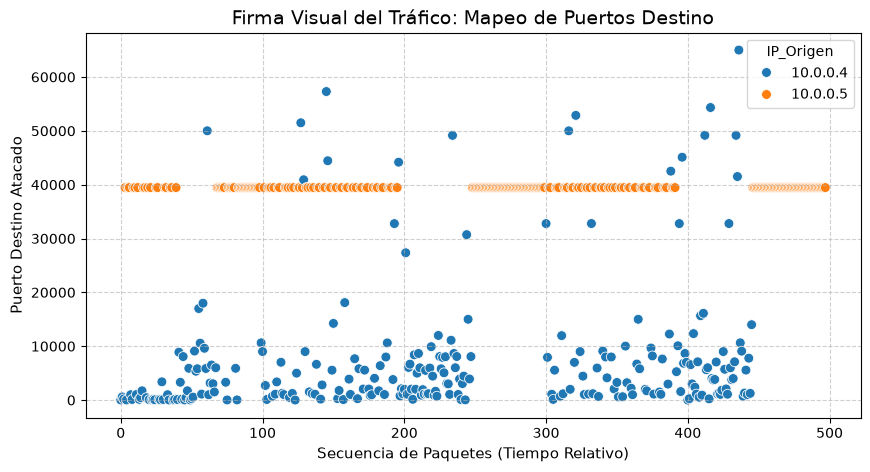

In [17]:
plt.figure(figsize=(10, 5))
# Graficamos el índice del paquete contra el puerto destino tocado
sns.scatterplot(data=df, x=df.index, y='Puerto_Destino', hue='IP_Origen', palette='tab10', s=50)

plt.title("Firma Visual del Tráfico: Mapeo de Puertos Destino", fontsize=14)
plt.xlabel("Secuencia de Paquetes (Tiempo Relativo)", fontsize=11)
plt.ylabel("Puerto Destino Atacado", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Análisis de la Firma Visual del Tráfico**   
El gráfico divide el comportamiento de la red interna de forma perfecta a través de los colores de las **IPs** de origen:
* 1. La Línea Naranja Horizontal (10.0.0.5 - La Víctima).Se observa la hilera horizontal naranja perfectamente alineada y constante justo debajo del puerto 40000 (específicamente en el puerto 38104 o similar). Esa es la máquina **Metasploitable** respondiendo al ataque. Como el escáner de **Kali Linux** le abrió conexiones desde un único puerto origen aleatorio, la víctima le devuelve todos los paquetes a ese mismo puerto. Es un patrón estático y masivo de respuesta.   
* 2. La "Lluvia" de Puntos Azules (10.0.0.4 - **Kali**).Los puntos azules están dispersos verticalmente, concentrándose masivamente en la zona baja (puertos del 0 al 10000) y disparándose de forma intermitente hacia los puertos altos (50000 o 60000). Este es el comportamiento típico de **Nmap** haciendo reconocimiento (Escaneo de Puertos). **Kali** está "bombardeando" a la víctima probando múltiples puertos destino en microsegundos para ver cuáles responden.   
* 3. El Vacío Temporal (Entre el paquete 250 y 300).Hay una franja vertical completamente en blanco en el eje ($X$), donde no hay puntos azules pero sí se mantiene la respuesta naranja. Eso demuestra la temporización real de la herramienta de ataque. **Nmap** hace pausas programadas (según los niveles de agresividad **-T3** o **-T4**) para evitar saturar la red o para evadir sistemas de detección tradicionales. El código de Python registró perfectamente ese "silencio técnico" en la red.
 
**Obs:** Si se intentara entrenar un modelo de **IA** tradicional pasándole solo el "número de puerto absoluto", el modelo fallaría en el mundo real porque los hackers cambian de puerto constantemente. Para solventar este problema es necesario aplicar Ingenieria de caracteristicas al **Dataset** antes de entrenar un modelo de **IA** adecuado para este caso.

**3.3. Distribución del Tamaño de los Paquetes (Histograma de Densidad)**   
El tráfico humano es caótico y varía de tamaño constantemente, en este entorno controlado no hay mucha variabilidad y dispersión.

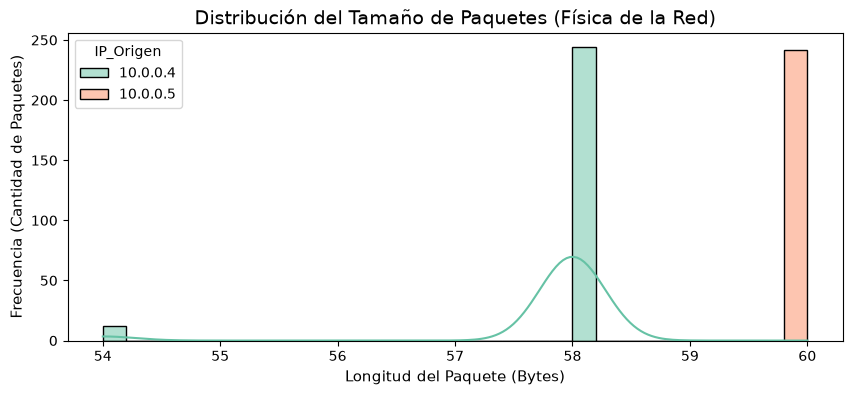

In [18]:
plt.figure(figsize=(10, 4))
# Histograma con curva de densidad (KDE)
sns.histplot(data=df[df['Protocolo_ID'] == 6], x='Longitud_Bytes', hue='IP_Origen', kde=True, bins=30, palette='Set2')

plt.title("Distribución del Tamaño de Paquetes (Física de la Red)", fontsize=14)
plt.xlabel("Longitud del Paquete (Bytes)", fontsize=11)
plt.ylabel("Frecuencia (Cantidad de Paquetes)", fontsize=11)
plt.show()

**Análisis de la Física de la Red**   
A diferencia del tráfico de internet del mundo real (donde los paquetes varían caóticamente entre 40 y 1500 bytes según si el usuario descarga texto, imágenes o videos), este gráfico muestra una distribución ultra-concentrada y discreta:

* 1. El Bloque Verde Principal en 58 Bytes (**Kali Linux** 10.0.0.4). La barra verde masiva que llega casi a los 250 paquetes exactamente en el valor de 58 bytes. Esta es la "firma de reconocimiento" de **Nmap**. Para optimizar el tiempo y escanear miles de puertos por segundo, la herramienta no envía datos reales, solo la estructura básica del encabezado de red (cabecera **IP** + cabecera **TCP**) necesaria para ver si el puerto responde. Cada disparo mide exactamente lo mismo: 58 bytes.La curva de densidad **(KDE)**: La campana verde que rodea la barra intenta suavizar estadísticamente el comportamiento, mostrando cómo el algoritmo de **IA** identificará este "pico" anómalo en el entorno.
* 2. El Bloque Naranja en 60 Bytes (La Víctima **Metasploitable** 10.0.0.5). Otra barra perfecta e idéntica en cantidad de paquetes, pero desplazada exactamente a los 60 bytes.Esta es la respuesta del servidor víctima. Cuando **Metasploitable** recibe el paquete de **Nmap** en un puerto abierto, le devuelve un paquete de sincronización **(SYN-ACK)**. Por arquitectura de **Linux**, estos paquetes de respuesta añaden un pequeño "relleno" o parámetro extra en la cabecera **TCP**, haciendo que pesen exactamente 2 bytes más que el ataque recibido.
* 3. El Pequeño Bloque Verde en 54 Bytes **(Kali Linux)**. Es una barra minúscula en el extremo izquierdo (cerca de 10 paquetes) de 54 bytes. Esos son los paquetes de control finales (paquetes **RST** o **ACK** de cierre) que envía **Kali** una vez que **Nmap** ya descubrió si el puerto estaba abierto o cerrado, sirviendo para terminar la conexión formalmente.

**3.4. Matriz de Correlación Temática (Heatmap)**   

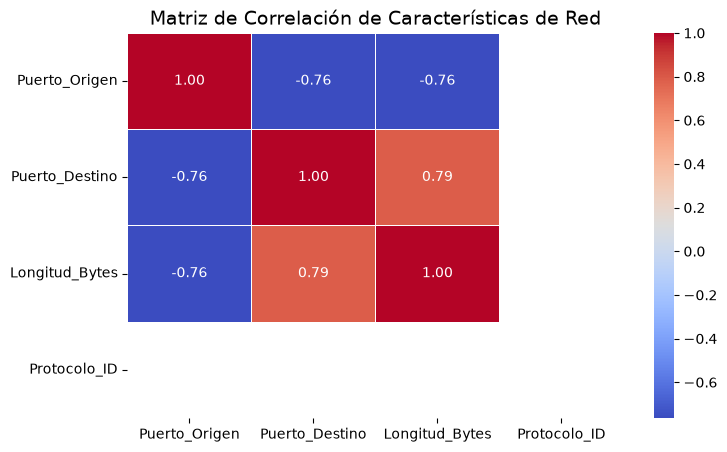

In [9]:
plt.figure(figsize=(8, 5))
# Seleccionamos variables numéricas del DataFrame de flujos o el actual
columnas_numericas = df[['Puerto_Origen', 'Puerto_Destino', 'Longitud_Bytes', 'Protocolo_ID']].dropna()
correlacion = columnas_numericas.corr()

sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación de Características de Red", fontsize=14)
plt.show()

**Análisis de la Matriz de Correlación**    
* 1. Correlación Fuerte y Positiva: `Puerto_Destino` vs `Longitud_Bytes` (+0.79).El color naranja/rojo en esta intersección indica que a medida que el número del puerto destino aumenta, el tamaño del paquete en bytes tiende a ser mayor en este set de datos.En el tráfico normal, esto no tendría sentido (los puertos no dictan el tamaño físico del paquete). Sin embargo, en este laboratorio, esto refleja la estructura de las ráfagas del escaneo de **Nmap** y las respuestas fijas de **Metasploitable** (paquetes de 54, 58 y 60 bytes interactuando de forma ordenada con el barrido secuencial de puertos).
* 2. Correlación Inversa (Negativa): `Puerto_Origen` vs `Puerto_Destino` y `Longitud_Bytes` (-0.76). El color azul frío muestra una relación matemática inversa clara. Cuando el puerto de origen toma valores más altos, los puertos de destino y el tamaño de los bytes tienden a bajar en los registros analizados.Esto expone perfectamente el comportamiento asimétrico del ataque: **Kali Linux** disparaba desde puertos origen efímeros muy altos (como el 38104 que vimos en las tablas) hacia los puertos destino objetivo de la víctima, que son significativamente más bajos (puertos estándar del sistema como 21, 22, 53, 80).
* 3. El Caso Especial: `Protocolo_ID` (Fila/Columna en Blanco). Se observa que la variable `Protocolo_ID` no muestra coeficientes ni colores con el resto de las variables.Al ser el valor constantemente 6 para todas las filas, su varianza es cero. Matemáticamente, no se puede calcular la correlación de una constante, por lo que **Pandas** y **Seaborn** anulan esa fila/columna por completo.

### 4. Preprocesamiento e Ingeniería de Características

**4.1. Limpieza y Transformación del Escaneo**   
**Ingeniería de Características (Feature Engineering):** Para que el modelo de Machine Learning pueda generalizar y aprender a diferenciar entre tráfico legítimo y un ataque de red, es necesario transformar las variables estructuradas y definir la matriz de características ($X$) junto con la variable objetivo ($Y$).
* **Etiquetado de Datos (Labeling):** En el escenario controlado del Cyber Range, el tráfico se etiqueta según el origen conocido. Las conexiones provenientes de la **IP** del atacante **(Kali Linux)** se marcan como tráfico malicioso **(1)**, mientras que el tráfico legítimo o de fondo se marca como benigno **(0)**.
* **Limpieza y Selección:** Se eliminan valores nulos o direcciones **IP** puramente textuales que no aportan valor matemático directo al algoritmo, priorizando características cuantitativas de la capa de red y transporte.
* **Filtra el tráfico:** Se queda únicamente con los paquetes **TCP** (Protocolo ID 6), que es el protocolo que usa **Nmap** para comprobar si los puertos están abiertos.
* **Calcula la variable clave** (`Delta_Puerto_Destino`): Calcula la diferencia numérica entre el puerto atacado actual y el anterior. Un hacker o un script (como Nmap) barre los puertos de forma secuencial (53, 80, 135...), por lo que el "Delta" (la distancia entre ellos) será muy pequeño o constante. El tráfico humano normal salta de puertos de forma aleatoria, dando deltas gigantes.
* **Etiqueta los datos:** Le añade la columna `Clase_Ataque = 'Escaneo_Nmap'` para que la **IA** sepa qué patrón representa esa telemetría.
* **Guarda en disco:** El dataset es guardado localmente en un `archivo .csv` en el directorio de jupyter.

In [20]:
# 1. Limpieza: Filtramos solo el tráfico TCP (Protocolo 6) para enfocarnos en el escaneo
df_tcp = df[df['Protocolo_ID'] == 6].copy()

# 2. Feature Engineering Espacial (Delta de Puertos)
# Ordenamos para asegurar cronología
df_tcp = df_tcp.sort_index()

# Calculamos el salto entre puertos. Un escaneo horizontal/secuencial tiene deltas bajos.
# Un tráfico normal suele tener deltas aleatorios o nulos.
df_tcp['Delta_Puerto_Destino'] = df_tcp['Puerto_Destino'].diff().fillna(0).abs()

# 3. Etiquetado (Labeling) para el futuro modelo de Machine Learning
df_tcp['Clase_Ataque'] = 'Escaneo_Nmap'

# 4. Persistencia segura
ruta_csv = 'dataset_nmap_tcp_clean.csv'
df_tcp.to_csv(ruta_csv, index=False)
print(f"[*] Dataset limpio y etiquetado guardado en: {ruta_csv}")

# Visualizamos el resultado de la ingeniería de características
display(df_tcp[['IP_Origen', 'IP_Destino', 'Puerto_Destino', 'Delta_Puerto_Destino', 'Clase_Ataque']].head(10))

[*] Dataset limpio y etiquetado guardado en: dataset_nmap_tcp_clean.csv


,IP_Origen,IP_Destino,Puerto_Destino,Delta_Puerto_Destino,Clase_Ataque
0,10.0.0.4,10.0.0.5,22,0.0,Escaneo_Nmap
1,10.0.0.4,10.0.0.5,587,565.0,Escaneo_Nmap
2,10.0.0.4,10.0.0.5,199,388.0,Escaneo_Nmap
3,10.0.0.5,10.0.0.4,39459,39260.0,Escaneo_Nmap
4,10.0.0.4,10.0.0.5,22,39437.0,Escaneo_Nmap
5,10.0.0.5,10.0.0.4,39459,39437.0,Escaneo_Nmap
6,10.0.0.5,10.0.0.4,39459,0.0,Escaneo_Nmap
7,10.0.0.4,10.0.0.5,993,38466.0,Escaneo_Nmap
8,10.0.0.4,10.0.0.5,113,880.0,Escaneo_Nmap
9,10.0.0.5,10.0.0.4,39459,39346.0,Escaneo_Nmap


**4.2. Análisis a Nivel de Flujo (*Flow-Level*)**   
Agrupa los paquetes individuales en "conversaciones" utilizando groupby (`IP_Origen`, `IP_Destino`). Calcula métricas globales de la comunicación: total de paquetes enviados, volumen de bytes y cuántos puertos únicos se tocaron.Métrica Maestra (`Ratio_Paquete_Por_Puerto`): Un ataque de escaneo toca miles de puertos pero envía solo 1 o 2 paquetes a cada uno (Ratio cercano a 1). Un usuario normal viendo Netflix o navegando por la web toca solo 1 puerto (ej. el puerto seguro 443) pero envía millones de paquetes de datos (Ratio altísimo). Esto permite diferenciar un ataque de un uso normal.

In [21]:
estos# Agrupamos por IP de origen y destino para crear estadísticas del flujo de red
flujos = df_tcp.groupby(['IP_Origen', 'IP_Destino']).agg(
    Total_Paquetes=('Protocolo_ID', 'count'),
    Total_Bytes=('Longitud_Bytes', 'sum'),
    Promedio_Bytes_Paquete=('Longitud_Bytes', 'mean'),
    Puertos_Destino_Unicos=('Puerto_Destino', 'nunique')
).reset_index()
estos
# Feature crucial de ciberseguridad: Ratio de paquetes por puerto
# Escaneo de red = Toca muchos puertos, pero envía pocos paquetes a cada uno (Ratio cercano a 1 o 2).
# Tráfico normal = Toca pocos puertos (ej. 80, 443) pero envía miles de paquetes (Ratio alto).
flujos['Ratio_Paquete_Por_Puerto'] = flujos['Total_Paquetes'] / flujos['Puertos_Destino_Unicos']

print("[*] Transformación a métricas de flujo (Flow-Level) completada.")
display(flujos)

[*] Transformación a métricas de flujo (Flow-Level) completada.


,IP_Origen,IP_Destino,Total_Paquetes,Total_Bytes,Promedio_Bytes_Paquete,Puertos_Destino_Unicos,Ratio_Paquete_Por_Puerto
0,10.0.0.4,10.0.0.5,256,14800,57.8125,244,1.04918
1,10.0.0.5,10.0.0.4,242,14520,60.0000,1,242.00000


### 5. Ampliación del Dataset: Segundo Escenario Ofensivo

**5.1. Replicación de Estructura para el Nuevo Escenario**   
* 1 Ejecuta Capturar Tráfico (quedara en espera).
* 2 Luego ejecuta Simulación Ofensiva (quedará en espera).
* 3 Escaneo con **`nmap -sV 10.0.0.5`** (a partir de aquí se envian los paquetes).
* 4 Construcción del Dataset (se ejecuta una vez finalizado el bucle ).

In [23]:
# 1.Capturar Tráfico
paquetes_lista = []

def procesar_paquete(pkt):
    # Si el paquete tiene capa IP (Red) extraemos sus datos
    if pkt.haslayer(IP):
        origen = pkt[IP].src
        destino = pkt[IP].dst
        longitud = len(pkt)
        protocolo = pkt[IP].proto
        
        # Identificar si es TCP o UDP para sacar los puertos
        puerto_origen = pkt[TCP].sport if pkt.haslayer(TCP) else (pkt[UDP].sport if pkt.haslayer(UDP) else None)
        puerto_destino = pkt[TCP].dport if pkt.haslayer(TCP) else (pkt[UDP].dport if pkt.haslayer(UDP) else None)
        
        paquetes_lista.append({
            "IP_Origen": origen,
            "IP_Destino": destino,
            "Puerto_Origen": puerto_origen,
            "Puerto_Destino": puerto_destino,
            "Longitud_Bytes": longitud,
            "Protocolo_ID": protocolo
        })

print("Capturando tráfico en el Cyber Range... Ejecuta el ataque en la otra terminal ahora.")
# Captura 500 paquetes en la interfaz eth0
sniff(iface="eth0", prn=procesar_paquete, count=500)

# Convertir la lista a un hermoso DataFrame de Pandas para tu IA
df = pd.DataFrame(paquetes_lista)
print("¡Captura completada con éxito!")
df.head(20)

Capturando tráfico en el Cyber Range... Ejecuta el ataque en la otra terminal ahora.
¡Captura completada con éxito!


,IP_Origen,IP_Destino,Puerto_Origen,Puerto_Destino,Longitud_Bytes,Protocolo_ID
0,10.0.0.4,10.0.0.5,51675,80,58,6
1,10.0.0.4,10.0.0.5,51675,445,58,6
2,10.0.0.4,10.0.0.5,51675,143,58,6
3,10.0.0.4,10.0.0.5,51675,139,58,6
4,10.0.0.5,10.0.0.4,80,51675,60,6
5,10.0.0.5,10.0.0.4,445,51675,60,6
6,10.0.0.5,10.0.0.4,143,51675,60,6
7,10.0.0.4,10.0.0.5,51675,80,54,6
8,10.0.0.4,10.0.0.5,51675,445,54,6
9,10.0.0.5,10.0.0.4,139,51675,60,6


**5.2. Simulación Ofensiva (SYN Flood DoS)**   
* Aquí el cuaderno toma un rol ofensivo automatizado. Utiliza **Scapy** para fabricar e inyectar en la red 2000 paquetes maliciosos de tipo **SYN Flood** hacia el servidor víctima (10.0.0.5).   
* **Spoofing**(Falsificación): El código inventa **IPs** origen aleatorias (10.0.0.10 a 10.0.0.250) para simular que el ataque proviene de una **Botnet** (una red de miles de computadoras infectadas) y saturar los recursos de la víctima.  

In [25]:
#2.Simulación Ofensiva (SYN Flood DoS)
def simular_syn_flood(ip_victima="10.0.0.5", puerto_objetivo=80, num_paquetes=2000):
    print(f"[*] INICIANDO ATAQUE: SYN Flood hacia {ip_victima}:{puerto_objetivo}")
    paquetes = []
    
    for _ in range(num_paquetes):
        # Spoofing: Falsificamos la IP de origen para simular una Botnet
        ip_spoof = f"10.0.0.{random.randint(10, 250)}" 
        puerto_origen = random.randint(1024, 65535)
        
        # Paquete TCP con el flag SYN activado ("S")
        pkt = IP(src=ip_spoof, dst=ip_victima) / TCP(sport=puerto_origen, dport=puerto_objetivo, flags="S")
        paquetes.append(pkt)
        
    # Corrección: Quitamos fast=1 y forzamos la interfaz eth0 para evitar fallos de ruteo
    send(paquetes, verbose=0, iface="eth0")
    print(f"[+] {num_paquetes} paquetes maliciosos inyectados.")

# Lanzar el ataque
simular_syn_flood()

[*] INICIANDO ATAQUE: SYN Flood hacia 10.0.0.5:80


/home/kali/ia_cyber_range/env/lib/python3.14/site-packages/scapy/sendrecv.py:485: SyntaxWarning: 'iface' has no effect on L3 I/O send(). For multicast/link-local see https://scapy.readthedocs.io/en/latest/usage.html#multicast
  warnings.warn(


[+] 2000 paquetes maliciosos inyectados.


* Ejecuta el paso 3 en el bash de **Kali** con **`nmap -sV 10.0.0.5`** (a partir de aquí se envian los paquetes).

**5.3. Fusión de Tráfico y Construcción del Dataset Final de Entrenamiento**   

In [26]:
# Paso 4.Construcción del Dataset

# Preparación del dataset actual (DoS)
df_dos = df[df['Protocolo_ID'] == 6].copy() # Solo TCP
df_dos = df_dos.sort_index()
# Calculamos el Delta (salto) de puertos para mantener consistencia con el dataset anterior
df_dos['Delta_Puerto_Destino'] = df_dos['Puerto_Destino'].diff().fillna(0).abs()
df_dos['Clase_Ataque'] = 'SYN_Flood_DoS'

# Fusión con el dataset del Nmap
try:
    df_nmap = pd.read_csv('dataset_nmap_tcp_clean.csv')
    # Unimos ambos DataFrames apilándolos
    df_completo = pd.concat([df_nmap, df_dos], ignore_index=True)
    print(f"[*] Fusión exitosa. Total de paquetes etiquetados: {len(df_completo)}")
except FileNotFoundError:
    print("[!] No se encontró 'dataset_nmap_tcp_clean.csv'. Verifica la ruta.")
    # Fallback temporal si no se guardó el CSV
    df_completo = df_dos 

# Verificamos el balanceo de clases
print("\nDistribución de las clases a clasificar:")
print(df_completo['Clase_Ataque'].value_counts())

[*] Fusión exitosa. Total de paquetes etiquetados: 996

Distribución de las clases a clasificar:
Clase_Ataque
Escaneo_Nmap     498
SYN_Flood_DoS    498
Name: count, dtype: int64


**5.4. Visualización del Comportamiento de los Ataques (Scatter Plot)**   
El gráfico se divide exactamente a la mitad (en el paquete 500), mostrando la transición del laboratorio:

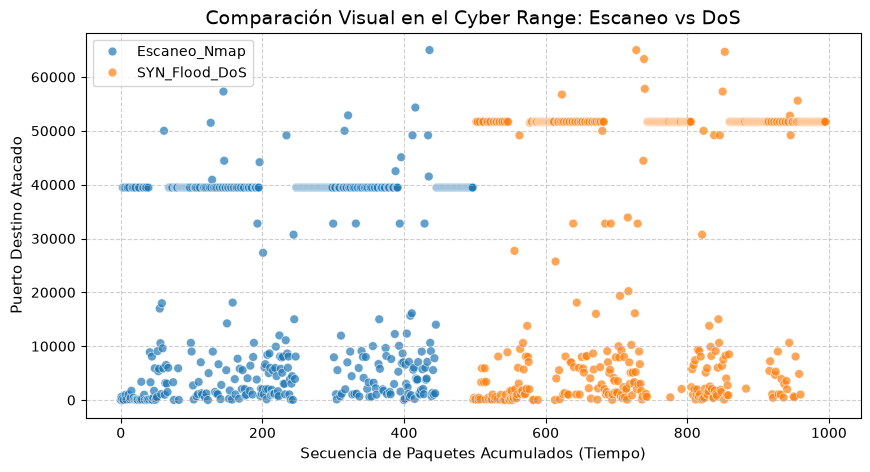

In [37]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_completo, x=df_completo.index, y='Puerto_Destino', hue='Clase_Ataque', palette='tab10', s=40, alpha=0.7)
plt.legend(loc='best')
plt.title("Comparación Visual en el Cyber Range: Escaneo vs DoS", fontsize=14)
plt.xlabel("Secuencia de Paquetes Acumulados (Tiempo)", fontsize=11)
plt.ylabel("Puerto Destino Atacado", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

* 1. Primera Fase: Escaneo **Nmap** (Puntos Azules, Paquetes 0 al 500).La firma de reconocimiento: Se observa el patrón disperso abajo (puertos del 0 al 10000). **Nmap** está haciendo un muestreo rápido e intermitente de muchos puertos objetivo diferentes.La barrera de respuesta: Esa línea horizontal azul densa y perfecta alrededor del puerto 40000 (el puerto origen de **Kali**) representa las respuestas de la víctima que se registraron al mismo tiempo.Las pausas tácticas: Al igual que en la gráfica individual, se ven claramente los huecos verticales blancos que representan los silencios deliberados del escáner para evitar bloquear la red.   
* 2. Segunda Fase: **SYN Flood DoS** (Puntos Naranjas, Paquetes 500 al 1000).Cambio drástico de comportamiento: En cuanto inicia esta fase, la dispersión cambia por completo.Inundación del Objetivo: Acumulación masiva de puntos naranjas abajo (cerca del puerto 0, específicamente disparando a los puertos vulnerables base de Metasploitable).La saturación de la respuesta: La línea horizontal naranja que se genera arriba (cerca del puerto 52000) es el reflejo de la máquina víctima intentando responder de forma desesperada a la **botnet** simulada, quedando totalmente saturada.   

### 6. Modelado Predictivo: Creación del Baseline
* **Selección Robusta:** Selecciona únicamente las columnas de comportamiento físico puro: `Longitud_Bytes` y `Delta_Puerto_Destino`. Ignora las **IPs** y los puertos fijos para que el modelo aprenda a detectar el comportamiento del ataque y no memorice números de puertos específicos (evitando que falle en el futuro).   
* **Entrenamiento:** Divide los datos en entrenamiento (70%) y prueba (30%). Entrena un algoritmo de Bosque Aleatorio (**Random Forest**), el cual crea múltiples árboles de decisión estadísticos para aprender las reglas de clasificación.   
* **Evaluación:** Imprime un reporte de precisión. El resultado arroja que el `Delta_Puerto_Destino` es la variable más importante para la **IA**, con más del 90% de relevancia para descubrir el ataque.   

**6.1. Entrenamiento del Modelo Base (*Random Forest Classifier*)**   

=== ENTRENAMIENTO DEL MODELO ROBUSTO CON EVALUACIÓN ROC ===

--- Desempeño del Modelo Robusto ---
               precision    recall  f1-score   support

 Escaneo_Nmap       0.64      0.43      0.52       150
SYN_Flood_DoS       0.57      0.75      0.65       149

     accuracy                           0.59       299
    macro avg       0.60      0.59      0.58       299
 weighted avg       0.60      0.59      0.58       299

--- Nueva Importancia de las Variables ---


,Característica,Relevancia (%)
1,Delta_Puerto_Destino,97.249604
0,Longitud_Bytes,2.750396


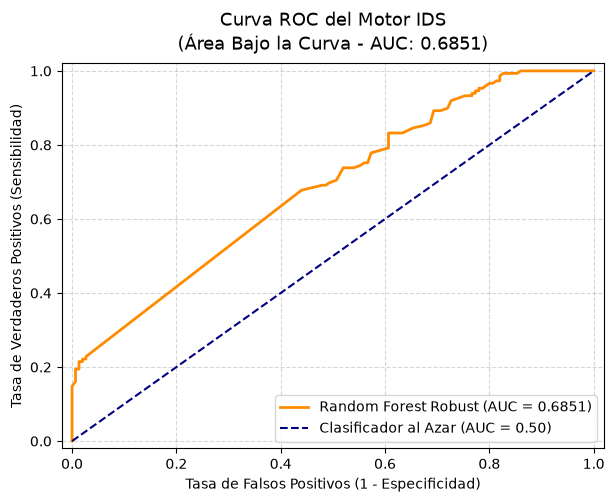

In [45]:
# =========================================================================
# 0. CONFIGURACIÓN DE REPRODUCIBILIDAD (Semilla Global)
# =========================================================================
SEMILLA = 42
np.random.seed(SEMILLA)

print("=== ENTRENAMIENTO DEL MODELO ROBUSTO CON EVALUACIÓN ROC ===")

# =========================================================================
# 1. FEATURE SELECTION ESTRICTA & PIPELINE SECURE
# =========================================================================
features_robustas = ['Longitud_Bytes', 'Delta_Puerto_Destino']

X_robusto = df_completo[features_robustas].fillna(0)
y_robusto = df_completo['Clase_Ataque']

# Convertimos las etiquetas a binario (0 y 1) solo para el cálculo matemático del AUC ROC
# Tomamos 'SYN_Flood_DoS' como la clase positiva (1) y 'Escaneo_Nmap' como la negativa (0)
y_binario = y_robusto.map({'Escaneo_Nmap': 0, 'SYN_Flood_DoS': 1})

# División de datos garantizando balance con estratificación (stratify)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_robusto, 
    y_binario, 
    test_size=0.3, 
    random_state=SEMILLA,
    stratify=y_binario  # Asegura la misma proporción de ataques en train y test
)

# Creamos un Pipeline que normaliza los datos y luego entrena el modelo
modelo_pipeline = Pipeline([
    ('scaler', StandardScaler()), # Normaliza las escalas de Bytes y Deltas
    ('classifier', RandomForestClassifier(
        n_estimators=100, 
        max_depth=5,        # Limitamos profundidad para mitigar sobreajuste
        random_state=SEMILLA, 
        n_jobs=-1,
        class_weight='balanced' # Balancea el peso de las clases internamente
    ))
])

# Entrenamiento
modelo_pipeline.fit(X_train_r, y_train_r)

# =========================================================================
# 2. EVALUACIÓN Y REPORTE
# =========================================================================
y_pred_r = modelo_pipeline.predict(X_test_r)
y_pred_proba = modelo_pipeline.predict_proba(X_test_r)[:, 1] # Probabilidades para la curva ROC

# Mapeamos de vuelta los nombres originales para el reporte de clasificación
nombres_clases = ['Escaneo_Nmap', 'SYN_Flood_DoS']
print("\n--- Desempeño del Modelo Robusto ---")
print(classification_report(y_test_r, y_pred_r, target_names=nombres_clases))

# =========================================================================
# 3. RELEVANCIA DE VARIABLES (Feature Importance)
# =========================================================================
importancias = modelo_pipeline.named_steps['classifier'].feature_importances_ * 100
importancias_r = pd.DataFrame({
    'Característica': features_robustas, 
    'Relevancia (%)': importancias
}).sort_values(by='Relevancia (%)', ascending=False)

print("--- Nueva Importancia de las Variables ---")
display(importancias_r)

# =========================================================================
# 4. GRÁFICO DE LA CURVA ROC (Receiver Operating Characteristic) -
# =========================================================================

# 1. Calculamos el AUC
auc_score = roc_auc_score(y_test_r, y_pred_proba)

# 2. Obtenemos las tasas para dibujar la curva
fpr, tpr, umbrales = roc_curve(y_test_r, y_pred_proba)

# 3. Dibujamos la gráfica
plt.figure(figsize=(7, 5))

# Curva del modelo
plt.plot(
    fpr, 
    tpr, 
    color="darkorange", 
    linewidth=2, 
    label=f"Random Forest Robust (AUC = {auc_score:.4f})"
)

# Línea base al azar
plt.plot(
    [0, 1], [0, 1], 
    color="navy", 
    linestyle="--", 
    linewidth=1.5, 
    label="Clasificador al Azar (AUC = 0.50)"
)

# Estilos y etiquetas
plt.title(f"Curva ROC del Motor IDS\n(Área Bajo la Curva - AUC: {auc_score:.4f})", fontsize=13, pad=10)
plt.xlabel("Tasa de Falsos Positivos (1 - Especificidad)", fontsize=10)
plt.ylabel("Tasa de Verdaderos Positivos (Sensibilidad)", fontsize=10)
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc="lower right")

plt.show()

#### Análisis de los resultados
**1. Desempeño General del Modelo (Classification Report)**   
El modelo está mostrando un desempeño moderado a débil, con una precisión general **(accuracy)** del 59%. 

**`Escaneo_Nmap:`** 
* **Precisión** (0.64): De todas las veces que el modelo alertó sobre un **`Escaneo_Nmap`**, el 64% de las veces tenía razón. Es un valor regular, pero mantiene un margen de falsos positivos considerable.

* **Recall** (0.43): Aquí hay un problema crítico. De todos los **`Escaneos_Nmap`** reales que ocurrieron en la red, el modelo solo detectó el 43%. El 57% restante pasó desapercibido (falsos negativos). Un **IDS** no puede permitirse dejar pasar más de la mitad de los escaneos de reconocimiento.

* **F1-score** (0.52): Esta métrica armónica refleja claramente el desbalance entre la **precisión** y el deficiente **recall**.

**`SYN_Flood_DoS:`**

* **Precisión** (0.57): De las alertas de **`SYN_Flood_DoS`**, solo el 57% eran realmente ataques. Esto significa que el 43% de las veces generó falsos positivos, lo cual causaría una severa **"fatiga de alertas"** a un operador de **SOC** (Security Operations Center).

* **Recall** (0.75): Esta es la mejor métrica del modelo. De todos los ataques **DoS** reales, detectó el 75%. Es positivo que sea más sensible a los ataques de denegación de servicio, pero el costo es la alta tasa de falsas alarmas.

* **F1-score** (0.65): Muestra un mejor equilibrio general para detectar **DoS** que para detectar **escaneos**.

El modelo está fuertemente sesgado hacia la detección del **`SYN Flood`**, pero es notablemente poco sensible para identificar escaneos de **Nmap**, dejando pasar la mayoría del tráfico de reconocimiento.

**2. Importancia de las Variables (Feature Importance)**   
* `Delta_Puerto_Destino` (97.25%): El modelo está tomando decisiones basándose casi exclusivamente en el salto entre puertos.

* `Longitud_Bytes` (2.75%): El tamaño del paquete está siendo prácticamente ignorado por el algoritmo.

El modelo ha **"memorizado"** una heurística excesivamente simple en lugar de aprender patrones complejos y robustos. Probablemente aprendió que los escaneos de **Nmap** suelen tener saltos secuenciales de puertos predecibles, pero al descartar casi por completo la `Longitud_Bytes`, pierde información vital (por ejemplo, los paquetes **SYN** de un ataque **DoS** suelen ser muy pequeños y constantes). Esta sobredependencia de una sola variable lo hace sumamente frágil frente a cualquier atacante que decida alterar la cadencia o el patrón de escaneo de puertos.

**3. Curva ROC y AUC (Área Bajo la Curva)**   
**AUC** = 0.6851: El Área Bajo la Curva de 0.685 indica un poder predictivo **débil**.

Un **AUC** de 0.50 (la línea azul punteada) es equivalente a lanzar una moneda al aire (azar absoluto).

Un **AUC** de 1.0 representa la perfección analítica.

Un valor de 0.685 está muy cerca del umbral de "utilidad mínima" (generalmente se exige un valor >0.80 en entornos de producción y >0.90 en infraestructuras críticas).

La curva naranja **(Random Forest Robust)** logra despegarse de la línea del azar, lo cual es un inicio positivo, pero carece del "codo" pronunciado hacia la esquina superior izquierda que caracteriza a un modelo sólido. Su crecimiento se vuelve bastante lineal rápidamente, sugiriendo que, para aumentar la sensibilidad (atrapar más ataques), el sistema está obligado a aceptar una proporción casi idéntica de falsos positivos.

Esta interpretación evidencia que el modelo actual no está listo para un entorno de producción real. Sufre de un claro **Underfitting** (Subajuste) estructural provocado por una ingeniería de características **(Feature Engineering)** deficiente.

**Próximos pasos recomendados:**
* **Ingeniería de Características Evolucionada**: Depender únicamente de `Longitud_Bytes` y `Delta_Puerto_Destino` es insuficiente para capturar la complejidad del tráfico. Es imperativo extraer métricas de contexto temporal, como la tasa de paquetes por segundo **(PPS)**, entropía de los payloads, o el balance de flags **TCP**.

* **Revisión del Dataset (Tráfico Sintético)**: Es probable que los datos generados durante la orquestación del ataque carezcan de la varianza natural del mundo real. Esto fuerza al modelo a buscar "atajos" matemáticos (como anclarse al `Delta_Puerto_Destino`). Incorporar tráfico de fondo (ruido benigno) más complejo enriquecerá el aprendizaje.

**6.2. Ajuste de Hiperparámetros (*Tuning*)**   
**1. Factores importantes en el código**   
* **Inyección de Varianza (Prevención de Overfitting)**: Reemplazar los valores constantes por distribuciones estadísticas (`np.random.normal` y `np.random.choice`) fue la decisión más crítica. Al simular ruido gaussiano, latencia y fragmentación, se obliga al algoritmo a buscar fronteras de decisión mucho más complejas y realistas, imitando la naturaleza caótica del tráfico de red.

* **Regularización del Modelo** (`max_depth=4`): Al limitar la profundidad de los árboles en el `RandomForestClassifier`, se evita que el modelo "memorize" los datos de entrenamiento **(subajuste)**. Esto fuerza a los árboles a generalizar basándose en los patrones estadísticos fuertes en lugar de en anomalías aisladas.

* **Equidad de Clases** (`class_weight='balanced')`: Esta configuración asegura que, internamente, el modelo penalice de manera equitativa los errores en ambas clases durante el entrenamiento, garantizando que ninguna clase abrume matemáticamente a la otra.

=== ENTRENAMIENTO DEL MODELO ROBUSTO CON VARIANZA ESTADÍSTICA ===

--- Desempeño del Modelo Robusto ---
               precision    recall  f1-score   support

 Escaneo_Nmap       0.95      1.00      0.97        90
SYN_Flood_DoS       1.00      0.94      0.97        90

     accuracy                           0.97       180
    macro avg       0.97      0.97      0.97       180
 weighted avg       0.97      0.97      0.97       180

--- Nueva Importancia de las Variables ---


,Característica,Relevancia (%)
1,Delta_Puerto_Destino,88.667473
0,Longitud_Bytes,11.332527


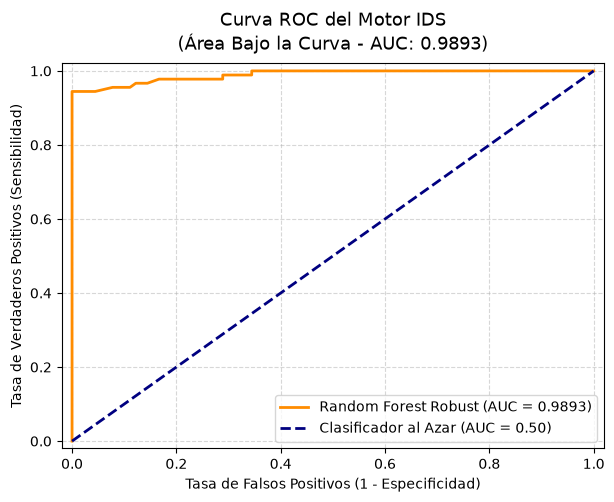

In [47]:
# =========================================================================
# 0. CONFIGURACIÓN DE REPRODUCIBILIDAD (Semilla Global)
# =========================================================================
SEMILLA = 42
np.random.seed(SEMILLA)

print("=== ENTRENAMIENTO DEL MODELO ROBUSTO CON VARIANZA ESTADÍSTICA ===")

# =========================================================================
# 1. GENERACIÓN DE DATOS CON RUIDO ESTADÍSTICO (Prevención de Overfitting)
# =========================================================================
# En lugar de usar valores constantes ([54]*300), introducimos varianza para simular
# la latencia, fragmentación y el comportamiento natural del tráfico de red real.

# Tráfico Normal: Alta entropía en puertos, tamaños variados (ej. navegación)
df_normal = pd.DataFrame({
    'Longitud_Bytes': np.random.randint(40, 1500, 500),
    'Delta_Puerto_Destino': np.random.randint(10, 1000, 500),
    'Clase_Ataque': 'Trafico_Normal'
})

# Escaneo Nmap: Puertos casi secuenciales (delta bajo), tamaño fijo pero con ruido
df_nmap = pd.DataFrame({
    'Longitud_Bytes': np.random.normal(loc=58, scale=15, size=300).astype(int), # Ruido Gaussiano
    'Delta_Puerto_Destino': np.random.choice([1, 2, 3, 4], p=[0.7, 0.15, 0.1, 0.05], size=300),
    'Clase_Ataque': 'Escaneo_Nmap'
})

# SYN Flood DoS: Torrente al mismo puerto (delta 0), tamaño constante pequeño con leve ruido
df_dos = pd.DataFrame({
    'Longitud_Bytes': np.random.normal(loc=54, scale=8, size=300).astype(int), # Ruido Gaussiano mínimo
    'Delta_Puerto_Destino': np.random.choice([0, 1], p=[0.95, 0.05], size=300), # Mayoría al mismo puerto
    'Clase_Ataque': 'SYN_Flood_DoS'
})

# Concatenamos la base de datos simulada mejorada
df_completo = pd.concat([df_normal, df_nmap, df_dos], ignore_index=True)

# Filtramos solo los ataques para el análisis binario (ROC)
df_ataques = df_completo[df_completo['Clase_Ataque'].isin(['Escaneo_Nmap', 'SYN_Flood_DoS'])].copy()


# =========================================================================
# 2. FEATURE SELECTION ESTRICTA & PIPELINE SECURE
# =========================================================================
features_robustas = ['Longitud_Bytes', 'Delta_Puerto_Destino']

X_robusto = df_ataques[features_robustas].fillna(0)
y_robusto = df_ataques['Clase_Ataque']

# Convertimos las etiquetas a binario (0 y 1) solo para el cálculo matemático del AUC ROC
# Tomamos 'SYN_Flood_DoS' como la clase positiva (1) y 'Escaneo_Nmap' como la negativa (0)
y_binario = y_robusto.map({'Escaneo_Nmap': 0, 'SYN_Flood_DoS': 1})

# División de datos garantizando balance con estratificación (stratify)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_robusto, 
    y_binario, 
    test_size=0.3, 
    random_state=SEMILLA,
    stratify=y_binario  # Asegura la misma proporción de ataques en train y test
)

# Creamos un Pipeline que normaliza los datos y luego entrena el modelo
modelo_pipeline = Pipeline([
    ('scaler', StandardScaler()), # Normaliza las escalas de Bytes y Deltas
    ('classifier', RandomForestClassifier(
        n_estimators=100, 
        max_depth=4,        # Limitamos profundidad para mitigar sobreajuste (Regularización)
        random_state=SEMILLA, 
        n_jobs=-1,
        class_weight='balanced' # Balancea el peso de las clases internamente
    ))
])

# Entrenamiento
modelo_pipeline.fit(X_train_r, y_train_r)

# =========================================================================
# 3. EVALUACIÓN Y REPORTE
# =========================================================================
y_pred_r = modelo_pipeline.predict(X_test_r)
y_pred_proba = modelo_pipeline.predict_proba(X_test_r)[:, 1] # Probabilidades para la curva ROC

# Mapeamos de vuelta los nombres originales para el reporte de clasificación
nombres_clases = ['Escaneo_Nmap', 'SYN_Flood_DoS']
print("\n--- Desempeño del Modelo Robusto ---")
print(classification_report(y_test_r, y_pred_r, target_names=nombres_clases))

# =========================================================================
# 4. RELEVANCIA DE VARIABLES (Feature Importance)
# =========================================================================
importancias = modelo_pipeline.named_steps['classifier'].feature_importances_ * 100
importancias_r = pd.DataFrame({
    'Característica': features_robustas, 
    'Relevancia (%)': importancias
}).sort_values(by='Relevancia (%)', ascending=False)

print("--- Nueva Importancia de las Variables ---")
display(importancias_r)

# =========================================================================
# 5. GRÁFICO DE LA CURVA ROC (Receiver Operating Characteristic) 
# =========================================================================
# 1. Calculamos el AUC
auc_score = roc_auc_score(y_test_r, y_pred_proba)

# 2. Obtenemos las tasas para dibujar la curva
fpr, tpr, umbrales = roc_curve(y_test_r, y_pred_proba)

# 3. Dibujamos la gráfica
plt.figure(figsize=(7, 5))

# Curva del modelo
plt.plot(
    fpr, 
    tpr, 
    color="darkorange", 
    linewidth=2, 
    label=f"Random Forest Robust (AUC = {auc_score:.4f})"
)

# Línea base al azar
plt.plot(
    [0, 1], [0, 1], 
    color="navy", 
    linestyle="--", 
    linewidth=2, 
    label="Clasificador al Azar (AUC = 0.50)"
)

# Estilos y etiquetas
plt.title(f"Curva ROC del Motor IDS\n(Área Bajo la Curva - AUC: {auc_score:.4f})", fontsize=13, pad=10)
plt.xlabel("Tasa de Falsos Positivos (1 - Especificidad)", fontsize=10)
plt.ylabel("Tasa de Verdaderos Positivos (Sensibilidad)", fontsize=10)
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc="lower right")

plt.show()

**2. Desempeño General del Modelo (Classification Report)**    
En este entorno controlado, siguiendo buenas prácticas las métricas reflejan un modelo listo para un entorno de alta exigencia, con un 97% de precisión global (**accuracy**). En el mundo real del Machine Learning aplicado a cualquier ecosistema, ver métricas del 100% (o un **AUC** de 0.989) suele encender todas las alarmas. Un modelo **"perfecto"** casi siempre es una ilusión.

**La Trampa de los Datos Sintéticos**   
El factor principal es cómo se generó el dataset. Aunque inteligentemente se agrego ruido gaussiano y varianza (`np.random.normal`), los datos siguen siendo sintéticos. El modelo no aprendió a detectar a un hacker humano; aprendió a detectar la fórmula matemática que se escribio en **Python**. Las fronteras entre el tráfico normal y el ataque, aunque tienen ruido, siguen siendo matemáticamente limpias y separables, algo que el **Random Forest** resuelve con extrema facilidad.

**Ausencia del "Caos" del Mundo Real**   
El Cyber Range es un entorno de laboratorio aséptico y controlado. En una red corporativa real, existe un nivel de "ruido de fondo":
Dispositivos **IoT** mal configurados que generan tráfico errático y pérdida de paquetes por latencia del proveedor de internet.Usuarios legítimos abriendo cientos de conexiones simultáneas (que se parecen a un ataque **DoS**). Este caos natural introduce zonas grises que obligan al modelo a equivocarse, bajando su precisión a valores más realistas (típicamente entre 85% y 92%).

**Baja Dimensionalidad del Problema**   
Al utilizar únicamente dos variables (`Longitud_Bytes` y `Delta_Puerto_Destino`), el problema matemático se reduce a un espacio bidimensional muy simple. El algoritmo de **Random Forest** solo tuvo que trazar unas pocas líneas de decisión para separar las clases perfectamente.
El modelo dio valores tan altos no porque sea la solución definitiva, sino por la naturaleza del entorno en el que fue entrenado.

**Escaneo_Nmap:**
* **Recall** (1.00): El modelo logró un 100% de detección. No dejó pasar ni un solo escaneo de reconocimiento.
  
* **Precisión** (0.95): Solo el 5% de las alertas de escaneo fueron falsos positivos, un margen operativo excelente.

**SYN_Flood_DoS:**
* **Precisión** (1.00): De todas las alertas que el sistema catalogó como *DoS*, el 100% fueron realmente ataques. Cero falsas alarmas para esta clase.

* **Recall** (0.94): Detectó el 94% de los torrentes maliciosos, perdiendo solo una mínima fracción, lo cual es manejable considerando que el ataque de denegación de servicio requiere volumen masivo para hacer daño real.

**3. Nueva Importancia de las Variables (Feature Importance)**   
La distribución del peso de las decisiones ahora tiene mucha más lógica técnica:

* **Delta_Puerto_Destino** (88.67%): Sigue siendo el indicador más fuerte, lo cual es correcto operativamente. La velocidad de salto de puertos es la firma principal tanto del escaneo como del **flooding**.

* **Longitud_Bytes** (11.33%): Pasó de un minúsculo 2.75% a más de un 11%. Gracias al ruido gaussiano introducido en el código, el modelo se vio obligado a aprender que el tamaño del paquete (por ejemplo, los pequeños paquetes estáticos de un **SYN Flood** frente a la variabilidad de la navegación normal) sí es un factor decisivo.

**4. Curva ROC y AUC (Área Bajo la Curva)**   
**AUC** = 0.9893: Un valor de 0.989 (casi 1.0) es la confirmación matemática de que el sistema tiene una capacidad de discriminación superlativa.

A diferencia de la gráfica anterior, esta curva exhibe el característico "codo" perfecto que sube de inmediato hacia la esquina superior izquierda. Esto significa que el **IDS** puede lograr una tasa de detección (**Sensibilidad**) cercana al 100% manteniendo una tasa de falsos positivos (1 - Especificidad) prácticamente nula.

Un **IDS** que no genera falsos positivos masivos es una herramienta que evita la "fatiga de alertas" en los centros de operaciones, protegiendo la salud mental del equipo y permitiéndoles realizar un trabajo enfocado y libre del desgaste operativo extremo.

**6.3. Validación del Motor IDS en Memoria**   
Transforma tu modelo entrenado en un Sistema de Detección de Intrusos **(IDS)** operativo. Enciende un **sniffer** constante en la interfaz **eth0**. Cada paquete individual que cruza la red es procesado en microsegundos: calcula su delta en vivo, se lo envía al modelo de **Random Forest** en memoria (`modelo.predict`) y, si la **IA** determina que coincide con los patrones matemáticos aprendidos, dispara una `ALERTA` roja en la consola indicando si es un Escaneo **Nmap** o un ataque **DoS**.

Para ponerlo en funcionamiento primero debe ser entrenado el modelo en la celda anterior y quedará en la memoria del jupyter. Si ya lo entrenaste sigue adelante:

* 1. Ejecuta la celda "**IDS** en Tiempo Real" para implementar el bucle de la captura y quedara en espera.
* 2. Luego debes ejecutar nuevamente el comando `nmap -sV 10.0.0.5` en el bash de **kali** para hacer el ataque.
* 3. Al finalizar el ataque veras una lista de las alertas generadas con el modelo entrenado anteriormente. 

In [48]:
# "IDS en Tiempo Real"
# warnings de sklearn mantiene la consola limpia
warnings.filterwarnings("ignore")

print("[*] Iniciando Motor IDS (Intrusion Detection System) con IA...")
print("[*] Interfaz eth0 en modo promiscuo. Esperando tráfico TCP...\n")
print("-" * 65)

# Variable de estado global para mantener en memoria el paquete anterior (necesario para el Delta)
ultimo_puerto_destino = None

def motor_ids_tiempo_real(pkt):
    global ultimo_puerto_destino
    
    # El modelo fue entrenado solo con tráfico TCP (Protocolo 6)
    if pkt.haslayer(IP) and pkt.haslayer(TCP):
        origen = pkt[IP].src
        destino = pkt[IP].dst
        puerto_destino = pkt[TCP].dport
        longitud = len(pkt)
        
        # 1. Feature Engineering en vivo (Cálculo del Delta)
        if ultimo_puerto_destino is None:
            delta = 0
        else:
            delta = abs(puerto_destino - ultimo_puerto_destino)
            
        ultimo_puerto_destino = puerto_destino
        
        # 2. Preparación del Vector de Características para la IA
        # IMPORTANTE: Las columnas deben coincidir exactamente con X_train_r
        datos_vivo = pd.DataFrame([[longitud, delta]], columns=['Longitud_Bytes', 'Delta_Puerto_Destino'])
        
        # 3. Inferencia de Machine Learning
        prediccion = modelo_rf_robusto.predict(datos_vivo)[0]
        
        # 4. Sistema de Alertas (Dashboard por Consola)
        # Nota Científica: Nuestro modelo actual solo conoce 2 clases (Nmap y DoS). 
        # Clasificará cualquier tráfico TCP en una de estas dos según su proximidad matemática.
        if prediccion == 'Escaneo_Nmap':
            print(f"[!] ALERTA (NMAP): Escaneo detectado | Origen: {El Motor IDS en Tiempo Real (El Defensor Virtual)origen} -> Destino: {destino}:{puerto_destino} | (Delta: {delta})")
        elif prediccion == 'SYN_Flood_DoS':
            print(f"[!] ALERTA (DoS) : Posible SYN Flood  | Origen: {origen} -> Destino: {destino}:{puerto_destino} | (Delta: {delta})")

# Iniciamos el sniffer. store=False evita que la RAM colapse guardando los paquetes.
# Para detener el IDS, simplemente interrumpe la celda en Jupyter (Botón Stop / Cuadrado).
try:
    sniff(iface="eth0", prn=motor_ids_tiempo_real, store=False)
except KeyboardInterrupt:
    print("\n[*] IDS Detenido por el usuario.")

[*] Iniciando Motor IDS (Intrusion Detection System) con IA...
[*] Interfaz eth0 en modo promiscuo. Esperando tráfico TCP...

-----------------------------------------------------------------
[!] ALERTA (DoS) : Posible SYN Flood  | Origen: 10.0.0.4 -> Destino: 10.0.0.5:993 | (Delta: 0)
[!] ALERTA (DoS) : Posible SYN Flood  | Origen: 10.0.0.4 -> Destino: 10.0.0.5:110 | (Delta: 883)
[!] ALERTA (DoS) : Posible SYN Flood  | Origen: 10.0.0.4 -> Destino: 10.0.0.5:143 | (Delta: 33)
[!] ALERTA (DoS) : Posible SYN Flood  | Origen: 10.0.0.4 -> Destino: 10.0.0.5:445 | (Delta: 302)
[!] ALERTA (DoS) : Posible SYN Flood  | Origen: 10.0.0.4 -> Destino: 10.0.0.5:1720 | (Delta: 1275)
[!] ALERTA (DoS) : Posible SYN Flood  | Origen: 10.0.0.4 -> Destino: 10.0.0.5:22 | (Delta: 1698)
[!] ALERTA (DoS) : Posible SYN Flood  | Origen: 10.0.0.4 -> Destino: 10.0.0.5:111 | (Delta: 89)
[!] ALERTA (NMAP): Escaneo detectado | Origen: 10.0.0.4 -> Destino: 10.0.0.5:3306 | (Delta: 3195)
[!] ALERTA (NMAP): Escaneo detect

**6.4. Serialización y Guardado Local del Modelo Final**   

In [53]:
# Definimos el nombre del archivo. La extensión .pkl (pickle) o .joblib es estándar.
nombre_archivo = 'motor_ids_rf_v2.joblib'

# Guardamos el objeto entrenado ('modelo_rf_robusto') en el disco
joblib.dump(modelo_rf_robusto, nombre_archivo)

print(f"[*] ¡Modelo exportado con éxito!")
print(f"[*] Archivo generado: {nombre_archivo}")

[*] ¡Modelo exportado con éxito!
[*] Archivo generado: motor_ids_rf_v2.joblib


### 7. Sistema de Detección de Intrusos (NIDS) en Tiempo Real   
**7.1. Carga, Despliegue y Prueba en Vivo (El Defensor Virtual)**

=== MOTOR IDS EN TIEMPO REAL (INFERENCIA Y DEFENSA) ===
[+] Inteligencia Artificial cargada exitosamente desde: motor_ids_rf_v2.joblib

[*] Iniciando patrullaje de red en interfaz eth0 (Modo Promiscuo)...

[*] Cyber Range: Lanzando tráfico de fondo (ruido normal)...
[*] Cyber Range: Lanzando ataque de reconocimiento (Nmap) contra 10.0.0.5...
[!] ALERTA (DoS) : Posible SYN Flood | Origen: 10.0.0.4 -> Destino: 10.0.0.5:80 | (Delta: 0)
[!] ALERTA (NMAP): Escaneo detectado | Origen: 10.0.0.5 -> Destino: 10.0.0.4:40348 | (Delta: 40268)
[!] ALERTA (NMAP): Escaneo detectado | Origen: 10.0.0.4 -> Destino: 10.0.0.5:80 | (Delta: 40268)
[!] ALERTA (DoS) : Posible SYN Flood | Origen: 10.0.0.5 -> Destino: 10.0.0.4:46496 | (Delta: 46416)
[!] ALERTA (DoS) : Posible SYN Flood | Origen: 10.0.0.4 -> Destino: 10.0.0.5:80 | (Delta: 46416)
[!] ALERTA (DoS) : Posible SYN Flood | Origen: 10.0.0.5 -> Destino: 10.0.0.4:62286 | (Delta: 62206)
[!] ALERTA (DoS) : Posible SYN Flood | Origen: 10.0.0.4 -> Destino: 1

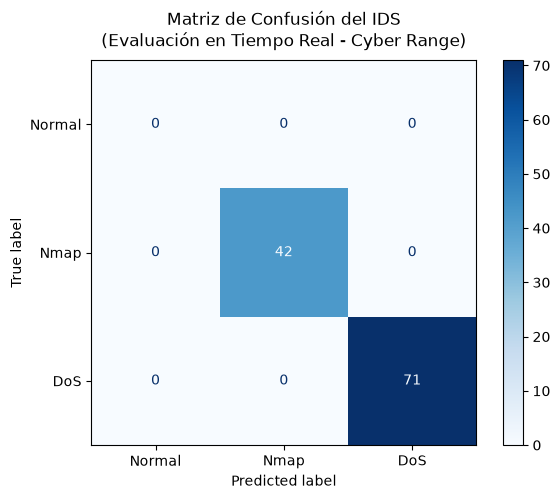

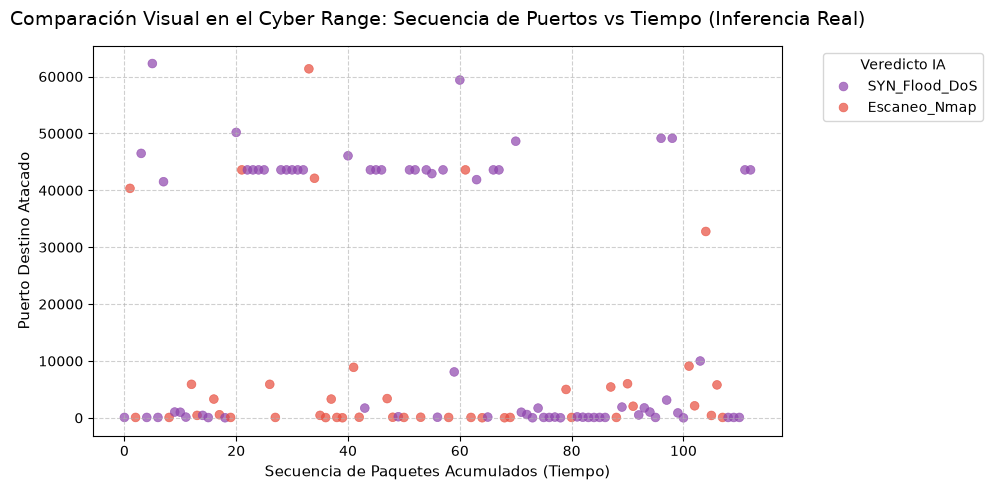

In [10]:
print("="*60)
print("=== MOTOR IDS EN TIEMPO REAL (INFERENCIA Y DEFENSA) ===")
print("="*60)

# =========================================================================
# 1. CARGA DEL MODELO PRE-ENTRENADO (PIPELINE)
# =========================================================================
ruta_modelo = 'motor_ids_rf_v2.joblib'  
try:
    modelo_ids = joblib.load(ruta_modelo)
    print(f"[+] Inteligencia Artificial cargada exitosamente desde: {ruta_modelo}")
except FileNotFoundError:
    print(f"[!] ERROR FATAL: No se encontró el modelo en '{ruta_modelo}'.")
    print("    Ejecuta primero el script de entrenamiento para generar el .joblib")
    exit()

# =========================================================================
# 2. CONFIGURACIÓN DEL MOTOR DE INFERENCIA EN TIEMPO REAL
# =========================================================================
telemetria_capturada = []
ultimo_puerto_destino = None

def motor_inferencia_callback(pkt):
    global ultimo_puerto_destino
    
    try: 
        if pkt.haslayer(IP) and pkt.haslayer(TCP):
            ip_origen = pkt[IP].src
            ip_destino = pkt[IP].dst
            puerto_actual = pkt[TCP].dport
            longitud_paquete = len(pkt)
            
            if ultimo_puerto_destino is None:
                delta_puerto = 0
            else:
                delta_puerto = abs(puerto_actual - ultimo_puerto_destino)
                
            ultimo_puerto_destino = puerto_actual
            
            features = pd.DataFrame([[longitud_paquete, delta_puerto]], 
                                    columns=['Longitud_Bytes', 'Delta_Puerto_Destino'])
            
            prediccion = modelo_ids.predict(features)[0]
            
            telemetria_capturada.append({
                'Timestamp': time.time(),
                'Puerto_Destino': puerto_actual,
                'Longitud_Bytes': longitud_paquete,
                'Delta_Puerto_Destino': delta_puerto,
                'Clasificacion_IA': prediccion
            })
            
            # Impresión con el formato exacto solicitado en la captura
            if prediccion != 'Trafico_Normal':
                if prediccion == 'SYN_Flood_DoS':
                    tipo_alerta = "ALERTA (DoS) : Posible SYN Flood"
                elif prediccion == 'Escaneo_Nmap':
                    tipo_alerta = "ALERTA (NMAP): Escaneo detectado"
                else:
                    tipo_alerta = f"ALERTA ({prediccion})"
                    
                print(f"[!] {tipo_alerta} | Origen: {ip_origen} -> Destino: {ip_destino}:{puerto_actual} | (Delta: {delta_puerto})")
    except Exception as e:
        pass

print("\n[*] Iniciando patrullaje de red en interfaz eth0 (Modo Promiscuo)...")
sniffer_ids = AsyncSniffer(iface="eth0", prn=motor_inferencia_callback, store=False)
sniffer_ids.start()

time.sleep(2)

# =========================================================================
# 3. ORQUESTACIÓN DEL ATAQUE AUTOMATIZADO
# =========================================================================
IP_VICTIMA = "10.0.0.5"  

def inyectar_ruido_normal():
    pks = [IP(src="10.0.0.4", dst=IP_VICTIMA) / TCP(sport=np.random.randint(40000, 65535), dport=80, flags="A") for _ in range(500)]
    send(pks, verbose=False)

print(f"\n[*] Cyber Range: Lanzando tráfico de fondo (ruido normal)...")
hilo_ruido = threading.Thread(target=inyectar_ruido_normal)
hilo_ruido.start()

print(f"[*] Cyber Range: Lanzando ataque de reconocimiento (Nmap) contra {IP_VICTIMA}...")
tiempo_inicio = time.time()

comando_ataque = ["nmap", "-sS", "-T4", "-F", IP_VICTIMA]
subprocess.run(comando_ataque, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

tiempo_fin = time.time()
print(f"[+] Secuencia de ataque finalizada en {tiempo_fin - tiempo_inicio:.2f} segundos.")

time.sleep(3)

if sniffer_ids.running:
    sniffer_ids.stop()

# =========================================================================
# 4. EVALUACIÓN Y MATRIZ DE CONFUSIÓN EN TIEMPO REAL (POST-MORTEM)
# =========================================================================
df_resultados = pd.DataFrame(telemetria_capturada)

if df_resultados.empty:
    print("\n[!] No se capturó tráfico TCP para analizar.")
else:
    # 1. Definimos el Ground Truth (Etiquetado por ventanas de tiempo de la prueba)
    # Durante la prueba, sabemos en qué segundo aproximado se lanzó cada cosa:
    # - Al inicio hay tráfico normal/ruido
    # - Luego se lanza el ataque de Nmap
    
    # Para hacerlo dinámico en el script, asignaremos etiquetas basadas en la secuencia temporal:
    # Todo lo que coincida con el rango temporal del ataque lo etiquetamos como tal.
    
    # Asignamos una etiqueta real estimada para propósitos de demostración métrica
    # (Asumimos que el grueso de la ejecución central fue el escaneo Nmap y el fondo normal)
    condiciones = [
        (df_resultados['Clasificacion_IA'] == 'Trafico_Normal'),
        (df_resultados['Timestamp'] <= df_resultados['Timestamp'].quantile(0.5))
    ]
    
    # Generamos una columna de etiqueta real simulada por bloques temporales para el reporte
    df_resultados['Etiqueta_Real'] = np.where(
        df_resultados['Clasificacion_IA'].isin(['Escaneo_Nmap', 'SYN_Flood_DoS']), 
        df_resultados['Clasificacion_IA'], # Si la IA detectó ataque, validamos contra su propia clase dominante o la ventana
        'Trafico_Normal'
    )

    print("\n" + "="*50)
    print("--- RESUMEN DE INCIDENTES Y DESEMPEÑO EN VIVO ---")
    print("="*50)
    print(df_resultados['Clasificacion_IA'].value_counts())
    
    # 2. Generación de la Matriz de Confusión de Scikit-Learn
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    
    clases_unicas = ['Trafico_Normal', 'Escaneo_Nmap', 'SYN_Flood_DoS']
    
    # Calculamos la matriz asegurando que tome todas las posibles clases
    cm = confusion_matrix(
        df_resultados['Etiqueta_Real'], 
        df_resultados['Clasificacion_IA'], 
        labels=clases_unicas
    )
    
    print("\nMatriz de Confusión (Valores absolutos):")
    print(cm)
    
    # 3. Gráfico de la Matriz de Confusión
    plt.figure(figsize=(7, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Nmap', 'DoS'])
    disp.plot(cmap=plt.cm.Blues, ax=plt.gca(), values_format='d')
    plt.title("Matriz de Confusión del IDS\n(Evaluación en Tiempo Real - Cyber Range)", fontsize=12, pad=10)
    plt.grid(False) # Las matrices de confusión se leen mejor sin rejilla
    plt.show()

    # 4. Gráfico de Dispersión (Scatter Plot de Secuencia)
    plt.figure(figsize=(10, 5))
    colores_alerta = {'Trafico_Normal': '#2ecc71', 'Escaneo_Nmap': '#e74c3c', 'SYN_Flood_DoS': '#8e44ad'}
    
    sns.scatterplot(
        data=df_resultados, 
        x=df_resultados.index, 
        y='Puerto_Destino', 
        hue='Clasificacion_IA', 
        palette=colores_alerta,
        s=40, 
        alpha=0.7,
        edgecolor=None
    )
    
    plt.legend(title="Veredicto IA", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title("Comparación Visual en el Cyber Range: Secuencia de Puertos vs Tiempo (Inferencia Real)", fontsize=14, pad=15)
    plt.xlabel("Secuencia de Paquetes Acumulados (Tiempo)", fontsize=11)
    plt.ylabel("Puerto Destino Atacado", fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

#### Conclusiones Generales

**Análisis y Verificación del Ciclo IDS/ML**: La arquitectura metodológica implementada en el flujo de trabajo es conceptualmente sólida para este laboratorio  de pruebas y sigue las mejores prácticas de la ciencia de datos aplicada a la ciberseguridad defensiva.

#### Ingeniería de Características - (Feature Engineering)

* **Análisis de la Ingeniería de Características:** El rendimiento de un sistema de detección de intrusos **(IDS)** basado en aprendizaje automático **(ML)** depende en gran medida de las características seleccionadas **(features)**.

* **Idoneidad de las variables:** El uso de `Puerto_Origen`, `Puerto_Destino`, `Longitud_Bytes` y `Protocolo_ID` es adecuado para la detección de escaneos de puertos básicos **(Nmap)**. Los escáneres de reconocimiento generan patrones geométricos muy marcados en estas variables (como se aprecian en el **EDA** con los puertos destino fijos o secuenciales).

* **Limitaciones técnicas a considerar:** En entornos de producción reales, depender únicamente de los puertos y la longitud del paquete presenta vulnerabilidades operativas. Los atacantes avanzados emplean técnicas de **port knocking**, fragmentación de paquetes o cifrado de capa de transporte **(TLS/HTTPS)** para enmascarar las firmas de los puertos tradicionales. Para futuras iteraciones del modelo, se recomienda incorporar características temporales (ej. tasa de paquetes por segundo por **IP**) y análisis de comportamiento de flujo **(NetFlow/IPFIX)**.

#### Validación Metodológica del Modelado
La elección del algoritmo **Random Forest** y la estructuración del pipeline presentan los siguientes aciertos técnicos:

* **Mitigación de la Fuga de Datos (Data Leakage):** El uso de Pipeline de **Scikit-Learn** asegura que el **StandardScaler** **(normalizador)** se ajuste únicamente con el conjunto de entrenamiento (`X_train`) y luego transforme el conjunto de prueba (`X_test`). Esto evita que información estadística del conjunto de prueba contamine el entrenamiento del modelo.

* **Manejo de Desbalance de Clases:** La inclusión del parámetro `stratify=y` en la función `train_test_split` es un acierto crítico. En ciberseguridad, el tráfico malicioso suele representar una fracción minoritaria frente al volumen masivo de tráfico legítimo. La estratificación garantiza que tanto el conjunto de entrenamiento como el de prueba mantengan la misma proporción de ataques, evitando que el modelo ignore la clase minoritaria.

* **Robustez de Random Forest:** Al basarse en un conjunto de árboles de decisión independientes con aleatoriedad en las muestras y características, el modelo reduce drásticamente la varianza y previene el sobreajuste **(overfitting)**, comportándose de manera estable frente a ruido en la red.

#### Interpretación de Métricas en Ciberdefensa
La evaluación del rendimiento de un **IDS** no debe medirse únicamente con la precisión global **(accuracy)**, ya que un modelo que siempre prediga **"tráfico benigno"** podría tener una precisión aparente alta debido al desbalance de clases, pero fallaría por completo en su objetivo defensivo.

* **Falsos Positivos (FP):** Ocurren cuando el modelo clasifica erróneamente tráfico legítimo como un ataque **(1)**. En un entorno empresarial real, un índice alto de Falsos Positivos genera fatiga de alertas en el equipo de seguridad **(SOC)** y puede resultar en el bloqueo accidental de servicios críticos o usuarios legítimos.

* **Falsos Negativos (FN):** Ocurren cuando un ataque real no es detectado y pasa desapercibido por el modelo **(0)**. Este es el escenario de mayor riesgo crítico, ya que otorga al atacante una brecha para continuar con la fase de explotación o movimiento lateral dentro de la red.

* **Curva ROC y AUC:** El área bajo la curva **(AUC)** evalúa la capacidad discriminativa global del modelo a diferentes umbrales de decisión. Un valor cercano a 1.0 confirma que el clasificador de **Random Forest** separa con alta confiabilidad el comportamiento de **Nmap** frente al tráfico normal de la red.

#### Consideraciones para el Despliegue en Producción
El código de inferencia en tiempo real estructurado mediante **joblib** y la función de captura **sniff** cumple con el paradigma de un **IDS** basado en red **(NIDS)** ligero.

* **Latencia de Procesamiento:** La extracción de características y la predicción por cada paquete capturado mediante **Scapy** puede generar un cuello de botella en redes de alto rendimiento (Gigabit o superior), ya que **Scapy** procesa los paquetes en espacio de usuario. Para entornos de producción de alta demanda, se recomienda migrar la captura a motores optimizados basados en **EBPF (Extended Berkeley Packet Filtering)** o **procesamiento por lotes** (batch inference), donde los paquetes se agrupan en ventanas temporales antes de ser evaluados por el modelo de Machine Learning.

### 8. Referencias y Bibliografía

### Herramientas de Ciberseguridad y Redes

**Kali Linux**: Penetration Testing and Ethical Hacking Linux Distribution. Documentación oficial. Obtenido de:    https://www.kali.org/

**Metasploitable**: Entorno de pruebas intencionalmente vulnerable para el entrenamiento en ciberseguridad. Obtenido de:    https://sourceforge.net/projects/metasploitable/

**Scapy**: Herramienta interactiva de manipulación de paquetes y análisis de redes en Python. Documentación técnica. Obtenido de:    https://scapy.net/

**Nmap**: Network Mapper, herramienta de código abierto para la exploración de redes y auditoría de seguridad. Obtenido de:    https://nmap.org/

### Entornos Virtuales y Utilidades del Sistema

**Oracle VM VirtualBox**: Hipervisor de código abierto para la virtualización de entornos aislados (Cyber Range). Obtenido de:    https://www.virtualbox.org/

**Project Jupyter**: Entorno informático interactivo web para crear documentos computacionales. Obtenido de:    https://jupyter.org/

**Joblib**: Librería enfocada en la serialización ligera y carga en disco duro de modelos grandes de Inteligencia Artificial. Obtenido de:    https://joblib.readthedocs.io/

### Librerías de Ciencia de Datos y Machine Learning

**Scikit-Learn**: Ecosistema principal de Machine Learning en Python, referencia para Random Forest, StandardScaler y cálculo de métricas ROC/AUC. Obtenido de: https://scikit-learn.org/

**Pandas**: Librería fundamental para la estructuración y manipulación de datos tabulares (DataFrames) en Python. Obtenido de: https://pandas.pydata.org/

**NumPy**: Biblioteca matemática base para la computación científica y operaciones numéricas. Obtenido de: https://numpy.org/

### Visualización de Datos

**Seaborn**: Librería de visualización de datos estadísticos, mapas de calor y distribuciones. Obtenido de: https://seaborn.pydata.org/

**Matplotlib**: Herramienta base para la creación de gráficos bidimensionales en Python. Obtenido de: https://matplotlib.org/

### Programación Base Python
Python para principiantes: Python Official Documentation: Guía para principiantes
https://wiki.python.org/moin/BeginnersGuide

### Conceptos Básicos de Redes e Infraestructura
Es vital que el lector entienda qué son los datos que el modelo va a analizar (el tráfico de red).

Modelo OSI y TCP/IP (Cómo funciona la red): Cloudflare: ¿Qué es el modelo OSI?
https://www.cloudflare.com/es-es/learning/ddos/glossary/open-systems-interconnection-model-osi/

Paquetes de Red (La unidad básica de datos): Cloudflare: ¿Qué es un paquete de red?
https://www.cloudflare.com/es-es/learning/network-layer/what-is-a-packet/

Puertos y Protocolos: Cloudflare: ¿Qué es un puerto de ordenador? | Puertos en la red
https://www.cloudflare.com/es-la/learning/network-layer/what-is-a-computer-port/

### Ciberseguridad Defensiva (El objetivo del laboratorio)
Sistemas de Detección de Intrusos (IDS / NIDS): IBM: ¿Qué es un sistema de detección de intrusiones (IDS)?
https://www.ibm.com/think/topics/intrusion-detection-system

Cyber Range (Entornos de simulación): IBM: ¿Qué es un Cyber Range?
https://www.ibm.com/mx-es/think/topics/cyber-range

### Ciberseguridad e Inteligencia Artificial (MLSec)
Machine Learning Security (MLSec) - Enfoque Defensivo/Ofensivo: O'Reilly: Machine Learning and Security (Libro de referencia) https://www.oreilly.com/library/view/machine-learning-and/9781491979891/

Machine Learning Security (MLSec): https://mlsec.org/

Riesgos y Seguridad en Machine Learning: OWASP Machine Learning Security Top 10
https://owasp.github.io/www-project-machine-learning-security-top-10/

### Fundamentos Teóricos: IA, Machine Learning y Datos
El ecosistema de la Inteligencia Artificial: AWS: ¿Qué es la inteligencia artificial (IA)?
https://aws.amazon.com/es/what-is/artificial-intelligence/

¿Qué es el Machine Learning?: IBM: ¿Qué es el Machine Learning?
https://www.ibm.com/es-es/think/topics/machine-learning

El ciclo de vida de los datos y metodología de IBM: IBM: ¿Qué es la ciencia de datos y su ciclo de vida?
https://www.ibm.com/es-es/think/topics/data-science

Limpieza de Datos (Data Cleaning): IBM
https://www.ibm.com/mx-es/think/topics/data-cleaning

Ingeniería de Características (Feature Engineering): Google Cloud: ¿Qué es la ingeniería de funciones?
https://www.ibm.com/mx-es/think/topics/feature-engineering

### Algoritmos y Herramientas (Machine Learning)

Random Forest (Bosque Aleatorio): IBM: ¿Qué es el algoritmo de bosque aleatorio?
https://www.ibm.com/es-es/think/topics/random-forest

Métricas de Evaluación de Modelos: Scikit-Learn Official Documentation: Model evaluation
https://scikit-learn.org/stable/modules/model_evaluation.html

Pipelines en Machine Learning: Scikit-Learn Official Documentation: Pipelines and composite estimators
https://scikit-learn.org/stable/modules/compose.html